# Lab 2
exercise 1: exposure

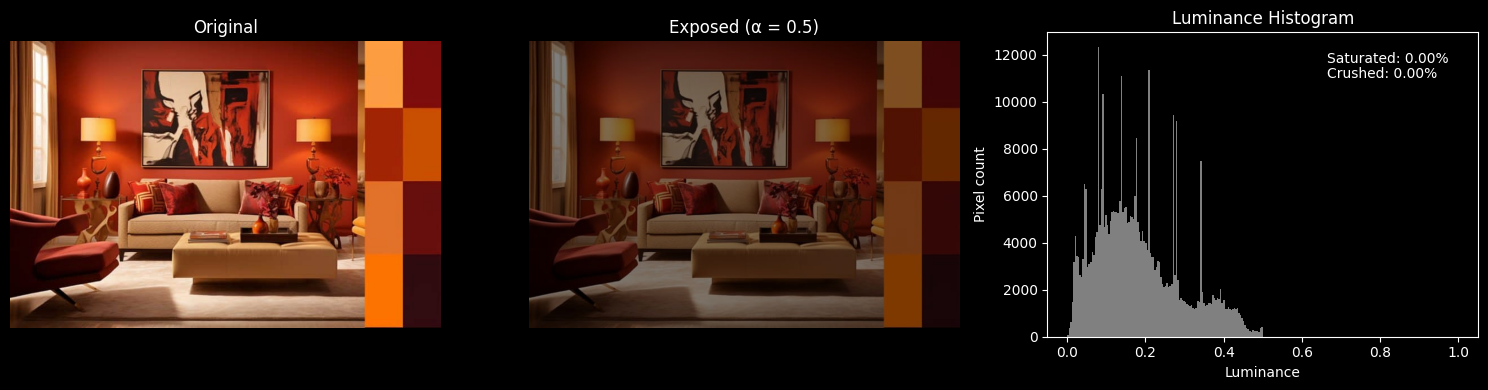

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load & normalize
img = cv2.imread("warm_picture.jpg").astype(np.float32) / 255.0

# Exposure
alpha = 0.5
exposed = np.clip(img * alpha, 0.0, 1.0)

# Luminance
Y = (
    0.299 * exposed[:,:,2] +
    0.587 * exposed[:,:,1] +
    0.114 * exposed[:,:,0]
)

# Statistics
sat_pct = np.mean(Y >= 0.99) * 100
crush_pct = np.mean(Y <= 0.00) * 100

# ---- DISPLAY ----
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Original image
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[0].axis("off")

# Exposed image
axes[1].imshow(cv2.cvtColor(exposed, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Exposed (α = {alpha})")
axes[1].axis("off")

# Histogram with stats overlay
axes[2].hist(Y.flatten(), bins=256, range=(0, 1), color='gray')
axes[2].set_title("Luminance Histogram")
axes[2].set_xlabel("Luminance")
axes[2].set_ylabel("Pixel count")

# Overlay the stats as text inside the histogram
axes[2].text(0.65, 0.9, f"Saturated: {sat_pct:.2f}%", transform=axes[2].transAxes)
axes[2].text(0.65, 0.85, f"Crushed: {crush_pct:.2f}%", transform=axes[2].transAxes)

plt.tight_layout()
plt.show()
